In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img
from lime import lime_image
from skimage.segmentation import mark_boundaries



C:\Users\PMLS\anaconda3\envs\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
Image_Size   = 128
class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

In [14]:
model = load_model('model.h5')
_ = model.predict(np.zeros((1, Image_Size, Image_Size, 3)), verbose=0)
print("Model ready.")

Model ready.


In [3]:
def load_for_inference(img_path):
    """Float32 tensor (1, H, W, 3) for model.predict."""
    img = load_img(img_path, target_size=(Image_Size, Image_Size))
    return np.expand_dims(np.array(img, dtype=np.float32) / 255.0, 0)

def load_uint8(img_path):
    """uint8 ndarray (H, W, 3) – needed by LIME."""
    img = load_img(img_path, target_size=(Image_Size, Image_Size))
    return np.array(img, dtype=np.uint8)

def load_rgb(img_path):
    """uint8 RGB via OpenCV (H, W, 3)."""
    bgr = cv2.resize(cv2.imread(img_path), (Image_Size, Image_Size))
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    

In [4]:
def grad_cam_plus_plus(img_array, model,
                       last_conv_layer_name="block5_conv3",
                       class_idx=None):
    """
    Returns normalised heatmap (H_conv, W_conv) in [0, 1].
    img_array : float32 (1, H, W, 3)
    """
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    base_model      = model.layers[0]
    last_conv_layer = base_model.get_layer(last_conv_layer_name)
    backbone        = tf.keras.Model(base_model.inputs, last_conv_layer.output)

    clf_in = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = clf_in
    layer_idx = base_model.layers.index(last_conv_layer)
    for layer in base_model.layers[layer_idx + 1:]:
        x = layer(x)
    for layer in model.layers[1:]:
        x = layer(x)
    classifier = tf.keras.Model(clf_in, x)

    with tf.GradientTape() as tape2:
        with tf.GradientTape() as tape1:
            conv_out = backbone(img_tensor)
            tape1.watch(conv_out)
            tape2.watch(conv_out)
            preds = classifier(conv_out)
            if class_idx is None:
                class_idx = int(tf.argmax(preds[0]))
            score = preds[:, class_idx]
        g1 = tape1.gradient(score, conv_out)
    g2 = tape2.gradient(g1, conv_out)

    alpha   = g2 / (2.0 * g2 +
                    tf.reduce_sum(conv_out * g2 * g1,
                                  axis=(1, 2), keepdims=True) + 1e-7)
    weights = tf.reduce_sum(alpha * tf.nn.relu(g1), axis=(1, 2))

    cam = tf.reduce_sum(
        conv_out[0] * weights[0][tf.newaxis, tf.newaxis, :], axis=-1
    )
    cam = tf.nn.relu(cam).numpy()
    cam -= cam.min()
    if cam.max() > 0:
        cam /= cam.max()
    return cam.astype(np.float32)



In [5]:
def run_lime(img_uint8, num_samples=1000, num_features=10, positive_only=True):
    """
    Returns (lime_overlay uint8, explanation, top_label_idx).
    lime_overlay has superpixel boundaries burned in.
    """
    def predictor(images):
        return model.predict(images.astype(np.float32) / 255.0, verbose=0)

    explainer   = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_uint8, predictor,
        top_labels=num_class,
        hide_color=0,
        num_samples=num_samples,
    )
    top_label = int(np.argmax(predictor(np.expand_dims(img_uint8, 0))[0]))
    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=positive_only,
        num_features=num_features,
        hide_rest=False,
    )
    overlay = (mark_boundaries(temp / 255.0, mask) * 255).astype(np.uint8)
    return overlay, explanation, top_label



In [38]:
def lime_predict(images):
    images = np.array(images)
    images = images.astype(np.float32) / 255.0
    return model.predict(images, verbose=0)

In [40]:
def explain_with_lime_overlay(img_path, model):
    img = load_img(img_path, target_size=(Image_Size, Image_Size))
    img = np.array(img)

    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        img.astype(np.float64),
        lime_predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000 
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    lime_overlay = (mark_boundaries(temp/255.0, mask) * 255).astype(np.uint8)

    return lime_overlay

In [29]:
def build_cam_overlay(img_rgb, heatmap, alpha=0.45):
    """Resize heatmap → JET colormap → blend with img_rgb. Returns uint8."""
    hm_up  = cv2.resize(heatmap, (Image_Size, Image_Size))
    hm_col = cv2.applyColorMap(np.uint8(255 * hm_up), cv2.COLORMAP_JET)
    hm_rgb = cv2.cvtColor(hm_col, cv2.COLOR_BGR2RGB)
    return np.clip(hm_rgb * alpha + img_rgb, 0, 255).astype(np.uint8)


In [30]:
def build_fused_overlay(img_rgb, cam_overlay, lime_overlay):
    fused = (img_rgb    * 0.35
           + cam_overlay * 0.30
           + lime_overlay * 0.35)
    return np.clip(fused, 0, 255).astype(np.uint8)


In [41]:
def unified_explanation_figure(
    img_path,
    num_lime_samples=1000,
    conv_layer="block5_conv3",
    num_features=10,
    save_path=None,
):
    """
    Draws one figure with 6 panels arranged in a 2×3 grid:

    Row 0: [Original MRI] [Grad-CAM++ overlay] [LIME boundaries]
    Row 1: [Triple Fused ] [Confidence bar    ] [Class prob table]
    """

    # ── 1. inference ────────────────────────────────────────
    img_arr    = load_for_inference(img_path)
    preds      = model.predict(img_arr, verbose=0)[0]          # (num_class,)
    pred_class = int(np.argmax(preds))
    confidence = float(np.max(preds))
    class_name = class_labels[pred_class]
    result_str = "No Tumor" if class_name == "notumor" else f"Tumor Detected: {class_name.capitalize()}"

    img_rgb    = load_rgb(img_path)
    img_uint8  = load_uint8(img_path)

    # ── 2. Grad-CAM++ ────────────────────────────────────────
    heatmap     = grad_cam_plus_plus(img_arr, model, conv_layer, pred_class)
    cam_overlay = build_cam_overlay(img_rgb, heatmap)

    # ── 3. LIME ──────────────────────────────────────────────
    print(f"[LIME] Running {num_lime_samples} perturbations …")
    lime_overlay = explain_with_lime_overlay(img_path, model)

    # ── 4. fused ─────────────────────────────────────────────
    fused = build_fused_overlay(img_rgb, cam_overlay, lime_overlay)

    # ── 5. layout ────────────────────────────────────────────
    fig = plt.figure(figsize=(20, 11), facecolor="#0d0d14")

    gs = gridspec.GridSpec(
        2, 3,
        figure=fig,
        hspace=0.38,
        wspace=0.18,
        left=0.04, right=0.96,
        top=0.88,  bottom=0.06,
    )

    ax_orig  = fig.add_subplot(gs[0, 0])
    ax_cam   = fig.add_subplot(gs[0, 1])
    ax_lime  = fig.add_subplot(gs[0, 2])
    ax_fused = fig.add_subplot(gs[1, 0])
    ax_bar   = fig.add_subplot(gs[1, 1])
    ax_tbl   = fig.add_subplot(gs[1, 2])

    IMG_AXES = [ax_orig, ax_cam, ax_lime, ax_fused]
    PANEL_STYLE = dict(color="#d0d0e8", fontsize=12, fontweight="bold", pad=9)

    # ── panel A – original ───────────────────────────────────
    ax_orig.imshow(img_rgb)
    ax_orig.set_title("Original MRI", **PANEL_STYLE)
    ax_orig.axis("off")
    _label_panel(ax_orig, "A")

    # ── panel B – Grad-CAM++ ─────────────────────────────────
    ax_cam.imshow(cam_overlay)
    ax_cam.set_title("Grad-CAM++ Heatmap", **PANEL_STYLE)
    ax_cam.axis("off")
    _add_colorbar(fig, ax_cam)
    _label_panel(ax_cam, "B")

    # ── panel C – LIME ───────────────────────────────────────
    ax_lime.imshow(lime_overlay)
    ax_lime.set_title("LIME Superpixel Explanation", **PANEL_STYLE)
    ax_lime.axis("off")
    _lime_legend(ax_lime)
    _label_panel(ax_lime, "C")

    # ── panel D – fused ──────────────────────────────────────
    ax_fused.imshow(fused)
    ax_fused.set_title("Fused: Original + CAM++ + LIME", **PANEL_STYLE)
    ax_fused.axis("off")
    _label_panel(ax_fused, "D")

    # ── panel E – horizontal confidence bar chart ────────────
    _draw_bar_chart(ax_bar, preds, pred_class)
    _label_panel(ax_bar, "E")

    # ── panel F – class probability table ───────────────────
    _draw_prob_table(ax_tbl, preds, class_labels, pred_class)
    _label_panel(ax_tbl, "F")

    # ── suptitle ─────────────────────────────────────────────
    verdict_color = "#ff6b6b" if class_name != "notumor" else "#6bff9e"
    fig.text(
        0.5, 0.944,
        result_str,
        ha="center", va="bottom",
        fontsize=19, fontweight="bold",
        color=verdict_color,
    )
    fig.text(
        0.5, 0.918,
        f"Confidence: {confidence*100:.1f}%   ·   "
        f"File: {os.path.basename(img_path)}   ·   "
        f"Model: VGG16 fine-tuned",
        ha="center", va="bottom",
        fontsize=10, color="#888899",
    )

    # ── frame every panel ────────────────────────────────────
    for ax in [ax_orig, ax_cam, ax_lime, ax_fused, ax_bar, ax_tbl]:
        for spine in ax.spines.values():
            spine.set_edgecolor("#2e2e44")
            spine.set_linewidth(1.2)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"[saved] {save_path}")

    plt.show()

In [42]:
def _label_panel(ax, letter):
    """White letter badge in top-left corner of each panel."""
    ax.text(
        0.02, 0.97, letter,
        transform=ax.transAxes,
        fontsize=14, fontweight="bold",
        color="white", va="top",
        bbox=dict(boxstyle="round,pad=0.2",
                  facecolor="#222233", edgecolor="none", alpha=0.7),
    )


def _add_colorbar(fig, ax):
    """Thin JET colorbar (Cold → Hot) below the CAM panel."""
    cax = fig.add_axes([
        ax.get_position().x0,
        ax.get_position().y0 - 0.025,
        ax.get_position().width,
        0.012,
    ])
    jet_cmap = plt.cm.jet
    cb = plt.colorbar(
        plt.cm.ScalarMappable(cmap=jet_cmap),
        cax=cax, orientation="horizontal"
    )
    cb.set_ticks([0, 0.5, 1])
    cb.set_ticklabels(["Low", "Mid", "High"])
    cb.ax.tick_params(colors="#aaaacc", labelsize=8)
    cb.outline.set_edgecolor("none")

In [43]:

def _lime_legend(ax):
    """Small legend: green = supporting, red = opposing."""
    patches = [
        mpatches.Patch(color="#00e676", label="Supporting"),
        mpatches.Patch(color="#ff5252", label="Opposing"),
    ]
    ax.legend(
        handles=patches, loc="lower right",
        fontsize=8, framealpha=0.55,
        facecolor="#111122", edgecolor="none",
        labelcolor="#ccccdd",
    )


In [44]:
def _draw_bar_chart(ax, preds, pred_class):
    """Horizontal bar chart of all class probabilities."""
    ax.set_facecolor("#111120")

    labels  = [c.capitalize() for c in class_labels]
    values  = [float(p) * 100 for p in preds]
    colors  = ["#ff6b6b" if i == pred_class else "#4dabf7"
               for i in range(len(labels))]
    y_pos   = np.arange(len(labels))

    bars = ax.barh(y_pos, values, color=colors,
                   height=0.55, edgecolor="none")

    # value labels inside / outside bars
    for bar, val in zip(bars, values):
        xpos = min(val + 1.5, 97)
        ax.text(xpos, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center",
                fontsize=9, color="#e0e0f0")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, color="#c8c8e0", fontsize=10)
    ax.set_xlim(0, 108)
    ax.set_xlabel("Confidence (%)", color="#888899", fontsize=9)
    ax.set_title("Top Predictions", color="#d0d0e8",
                 fontsize=12, fontweight="bold", pad=9)
    ax.tick_params(axis="x", colors="#666677", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_color("#2e2e44")
    ax.invert_yaxis()

    # highlight predicted class row
    ax.axhline(pred_class, color="#ffffff", linewidth=0.4, alpha=0.15,
               xmin=0, xmax=1)


In [45]:
def _draw_prob_table(ax, preds, class_labels, pred_class):
    """
    Clean styled table: rank / class / probability / risk level.
    """
    ax.set_facecolor("#111120")
    ax.axis("off")
    ax.set_title("Class Probability Summary", color="#d0d0e8",
                 fontsize=12, fontweight="bold", pad=9)

    risk_map = {
        "glioma":     "High",
        "meningioma": "Moderate",
        "pituitary":  "Moderate",
        "notumor":    "None",
    }
    risk_colors = {
        "High":     "#ff6b6b",
        "Moderate": "#ffd166",
        "None":     "#6bff9e",
    }

    order = np.argsort(preds)[::-1]
    col_labels = ["Rank", "Class", "Probability", "Risk"]
    rows = []
    for rank, idx in enumerate(order, 1):
        rows.append([
            str(rank),
            class_labels[idx].capitalize(),
            f"{preds[idx]*100:.2f}%",
            risk_map.get(class_labels[idx], "—"),
        ])

    tbl = ax.table(
        cellText=rows,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 2.0)

    # style header
    for col in range(len(col_labels)):
        cell = tbl[0, col]
        cell.set_facecolor("#1e1e32")
        cell.set_text_props(color="#a8a8d0", fontweight="bold")
        cell.set_edgecolor("#2e2e44")

    # style rows
    for row_i, (row_data, idx) in enumerate(zip(rows, order), 1):
        risk  = row_data[3]
        r_col = risk_colors.get(risk, "#cccccc")
        is_pred = (idx == pred_class)

        for col in range(len(col_labels)):
            cell = tbl[row_i, col]
            cell.set_facecolor("#1a1a2e" if not is_pred else "#1e2a1e")
            cell.set_edgecolor("#2e2e44")
            txt_color = (r_col if col == 3 else
                         "#ffe066" if is_pred else "#c8c8e0")
            cell.set_text_props(color=txt_color)



In [46]:
num_class    = len(class_labels)

[LIME] Running 1000 perturbations …


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:03<00:00, 15.86it/s]


[saved] unified_explanation.png


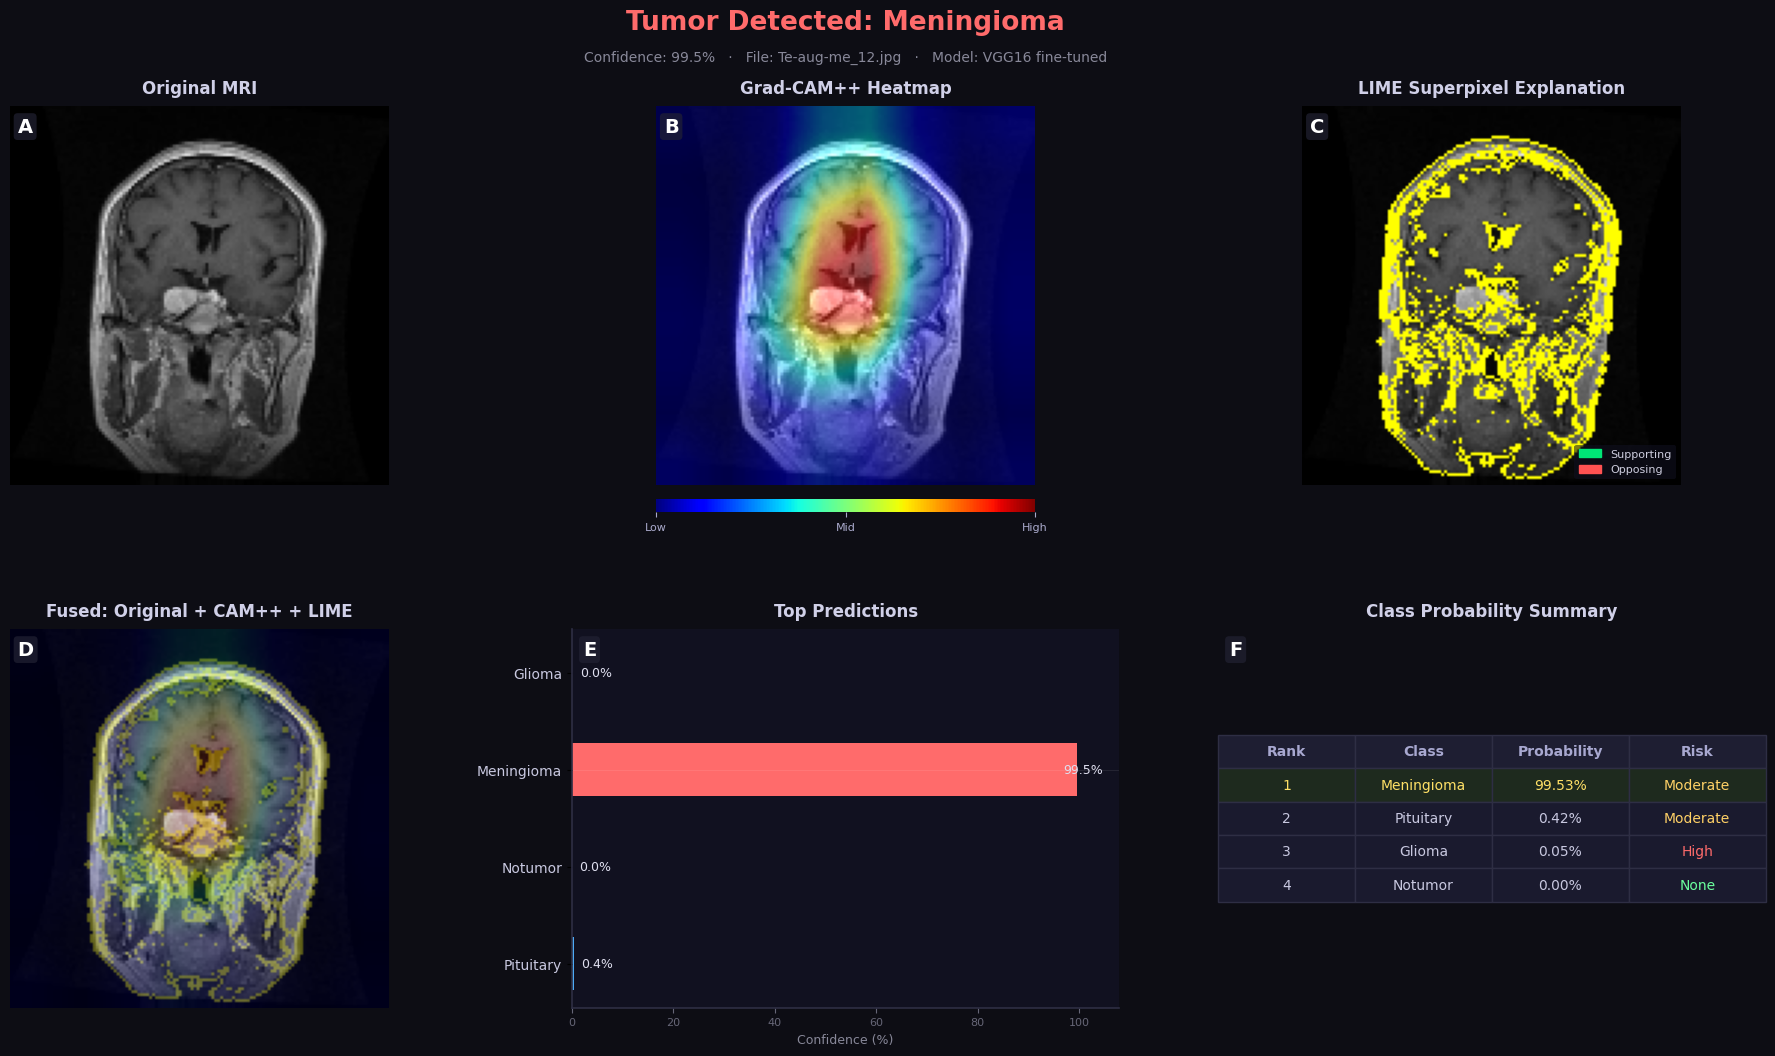

In [47]:
unified_explanation_figure(
    img_path       = 'MRI/Testing/meningioma/Te-aug-me_12.jpg',
    num_lime_samples = 1000,      # ↑ for smoother masks
    conv_layer     = "block5_conv3",
    num_features   = 10,
    save_path      = "unified_explanation.png",
)
